In [2]:
!pip install langchain -q
!pip install langchain-openai -q
!pip install langgraph -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 26.3 MB/s eta 0:00:00


In [3]:
from typing import Annotated, Sequence, TypedDict
from langchain_core.messages import BaseMessage, ToolMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

In [6]:
class AgentState(TypedDict):
  messages : Annotated[Sequence[BaseMessage],add_messages]  #msg sequence ekak vidihata use krna athara aluthin ena messages add wenva

In [7]:
import os
from google.colab import userdata

os.environ['OPENAI_API_KEY'] = userdata.get("OPENAI_API_KEY")

In [8]:
# Initialize the LLM

import os
from langchain_openai.chat_models import ChatOpenAI

llm = ChatOpenAI(
    model_name="gpt-4o",
    temperature=0.1,
)

In [9]:
# Initialize Custom Tools for the Agent

@tool
def addition(a: int, b: int) -> int:
    """Addition of two numbers"""    #This description is very important because the Agent is selecting the tool and knowing about the tool based on this description only
    return a + b

@tool
def substraction(a: int, b: int) -> int:
    """Substraction of two numbers"""
    return a - b


@tool
def division(a: int, b: int) -> int:
    """Division of two numbers"""
    return a / b

@tool
def multifycation(a: int, b: int) -> int:
    """Multifycation of two numbers"""
    return a * b

In [10]:
tools = [addition,substraction, division, multifycation]

In [11]:
tools_for_llm = llm.bind_tools(tools)   # Give the access for all the Tools to the LLM

In [12]:
# For how to use the tools

def llm_call(state : AgentState) -> AgentState:
  system_msg=SystemMessage(content="You're an intelligent AI assistant, please answer my query")
  response= tools_for_llm.invoke([system_msg] + state["messages"])  # llm t call krnne tool access dipu variable eken
  return {"messages": [response]}

In [13]:
# For get the decision what nodes will be selected

def get_decision(state : AgentState):
  messages=state["messages"]
  last_msg= messages[-1]
  if not last_msg.tool_calls:
    return "end"
  else :
    return "continue"

In [15]:
# Define Sequential Workflow

workflow= StateGraph(AgentState)

workflow.add_node("agent",llm_call)

tool_node= ToolNode(tools=tools) # Node for all the Tools
workflow.add_node("tools",tool_node)

workflow.add_edge(START,"agent")
workflow.add_conditional_edges(
    "agent",
    get_decision,
    {
        "continue": "tools",
        "end": END
    },
)
workflow.add_edge("tools","agent")

app= workflow.compile()

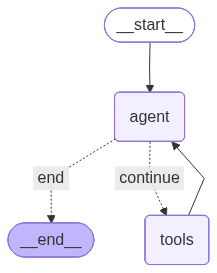

In [16]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [21]:
def print_stream(stream):
  for s in stream:
    message = s["messages"][-1]
    if isinstance(message,tuple):
      print(message)
    else:
      message.pretty_print()

In [24]:
inputs={"messages":[("user", "Add 12 and 56 then multify those")]}
print_stream(app.stream(inputs, stream_mode="values"))

================================ Human Message =================================

Add 12 and 56 then multify those
================================== Ai Message ==================================
Tool Calls:
  addition (call_2l4ZVEo1jsODRZ6t0CD66xNm)
 Call ID: call_2l4ZVEo1jsODRZ6t0CD66xNm
  Args:
    a: 12
    b: 56
  multifycation (call_SOKZYgUQtEkV444BGSQQoRd6)
 Call ID: call_SOKZYgUQtEkV444BGSQQoRd6
  Args:
    a: 12
    b: 56
================================= Tool Message =================================
Name: multifycation

672
================================== Ai Message ==================================

The sum of 12 and 56 is 68, and their multiplication is 672.
